# SECTION 1

In [2]:
#Load the dataset into Pandas.

import pandas as pd

df = pd.read_csv('sales_data.csv')

df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [3]:
#Display the number of rows and columns.

df.shape

(1000, 14)

In [4]:
#List all column names.
df.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

# SECTION 2

In [5]:
#Check the data types of all columns.
df.dtypes

Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object

In [11]:
#dentify - Numeric columns 
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns

Index(['Product_ID', 'Sales_Amount', 'Quantity_Sold', 'Unit_Cost',
       'Unit_Price', 'Discount'],
      dtype='object')

In [12]:
#Categorical Columns
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['Sale_Date', 'Sales_Rep', 'Region', 'Product_Category', 'Customer_Type',
       'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep'],
      dtype='object')

In [ ]:
#Explain what one row in the dataset represents
Explanation of Row 4 (Index 3)

On August 24, 2023, Bob made a retail sale in the South region, selling 39 units of a clothing product to a new customer,
with a 2% discount, paid via credit card, generating ₦2,167.94 in sales revenue.

# SECTION 3 - DATA QUALITY CHECKS

In [13]:
#Check for missing values in each column.
#This shows how many missing values exist in each column

df.isnull().sum()


Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [14]:
# Check for duplicate rows
#If the output is 0, there are no duplicate rows.
#If greater than 0, those rows may need to be removed

df.duplicated().sum()


0

In [ ]:
#Decide whether any cleaning is required and briefly explain your decision.
#Decision

#df.isnull().sum() returns all zero = No missing values

#If df.isnull().sum() returns all zeros → No missing values

#It impies the data is clean and does not reqire additional cleaning at this stage.It is suitable for analysis.
#If there were mising values and duplicates, data cleaning will be carried put. 
 

# SECTION 4 - CREATION FEATURE

In [49]:
#New column that represents profit per transaction.

#df['Profit'] = df['Unit_Price'] - df(['Unit_Cost'] * df['Quantity_Sold'])

# Create profit per transaction column

df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']

In [50]:
# Display selected columns to verify
df[['Unit_Price', 'Unit_Cost', 'Quantity_Sold', 'Profit']].head()
 

,Unit_Price,Unit_Cost,Quantity_Sold,Profit
0,267.22,152.75,18,2060.46
1,4209.44,3816.39,17,6681.85
2,371.40,261.56,30,3295.20
3,4467.75,4330.03,39,5371.08
4,692.71,637.37,13,719.42


# SECTION 5 -SALES OVERVIEW 

In [17]:
# Calculate the total sales amount.
#This gives the total revenue generated from all sales transactions in the dataset.

total_sales = df['Sales_Amount'].sum()
total_sales



5019265.2299999995

In [21]:
#Calculate the average sales amount per transaction

average_sales = df['Sales_Amount'].mean()
average_sales

5019.265229999999

In [27]:
#Identify the minimum sales amounts

min_sales = df['Sales_Amount'].min()
min_sales

100.12

In [28]:
#Identify maximum sales amounts

max_sales = df['Sales_Amount'].max()
max_sales

9989.04

# REGIONAL SALES ANALYSIS -SECTION 6

In [35]:
#Total sales by region.

sales_by_region = df.groupby('Region')['Sales_Amount'].sum()
sales_by_region


Region
East     1259792.93
North    1369612.51
South    1154250.86
West     1235608.93
Name: Sales_Amount, dtype: float64

In [37]:
#Average sales by region.

average_sales_by_region = df.groupby('Region')['Sales_Amount'].mean()
average_sales_by_region

Region
East     4790.087186
North    5129.634869
South    5107.304690
West     5063.971025
Name: Sales_Amount, dtype: float64

In [38]:
# Identify best_performing region
#The best-performing region is the one with the highest total sales, meaning it generates the most overall revenue.

best_region = sales_by_region.idxmax()
best_region


'North'

In [ ]:
#Total sales by region shows which region contributes the most revenue.
#Average sales by region indicates customer spending power and deal size.
#The best-performing region is the one with the highest total sales, meaning it generates the most overall revenue.
#The region with the highest total sales is the best-performing region overall, as it contributes the most to company revenue.

# SECTION 7 - PRODUCT ANALYSIS


In [39]:
#Analyze total sales by product category.

sales_by_product_category = df.groupby('Product_Category')['Sales_Amount'].sum()
sales_by_product_category

Product_Category
Clothing       1313474.36
Electronics    1243499.64
Food           1201773.54
Furniture      1260517.69
Name: Sales_Amount, dtype: float64

In [51]:
#Average quantity sold by product category.

average_quantity_sold_by_product_category = df.groupby('Product_Category')['Quantity_Sold'].mean()
average_quantity_sold_by_product_category

Product_Category
Clothing       25.828358
Electronics    24.780488
Food           24.814159
Furniture      25.880769
Name: Quantity_Sold, dtype: float64

In [52]:
#Identify which product category is the most profitable.
df.groupby('Product_Category')['Profit'].sum()

#furniture is most Profitable

Product_Category
Clothing       1712957.80
Electronics    1574320.06
Food           1421108.05
Furniture      1779461.16
Name: Profit, dtype: float64

# SECTION 8 - CUSTOMER ANALYSIS 

In [55]:
# SECTION 8 - CUSTOMER ANALYSIS 
#Compare average sales between customer types.
#Compare total profit between customer types.
#Identify which customer type is more valuable to the business

df.groupby('Customer_Type')['Sales_Amount'].mean()
#df.groupby('Customer_Type')['Profit'].sum()

Customer_Type
New          4972.734722
Returning    5066.546230
Name: Sales_Amount, dtype: float64

In [ ]:
#Identify which customer type is more valuable to the business

In [61]:
# SECTION 9: SALES REPRESENTATAIVE PERFORMANCE
#Analyze total sales by sales representative.
#Analyze average profit per sale by sales representative.
#Rank sales representatives based on performance.

#df.groupby('Sales_Rep')['Sales_Amount'].sum()
df.groupby('Sales_Rep')['Profit'].mean()
df.groupby('Sales_Rep')['Profit'].mean().sort_values(ascending=False)

Sales_Rep
Eve        6933.406220
David      6764.638559
Alice      6743.864635
Charlie    6339.604497
Bob        5628.847308
Name: Profit, dtype: float64

In [67]:
# SECTION 10:  FILTERING AND BUSINESS QUESTIONS
#Filter transactions with high sales amounts.
#Filter transactions that received discounts.
#Analyze whether discounted transactions appear to generate higher sales.

#high_sales = df[df['Sales_Amount'] > df['Sales_Amount'].mean()]
high_sales.shape

discounted = df[df['Discount'] > 0]
non_discounted = df[df['Discount'] ==0]
discounted['Sales_Amount'].mean(), non_discounted['Sales_Amount'].mean()

(5027.5216565040655, 4511.495000000001)

In [68]:
#Filter transactions with high sales amounts.
high_sales = df[df['Sales_Amount'] > df['Sales_Amount'].mean()]
high_sales.shape

(500, 15)

In [70]:
#Filter transactions that received discounts.
discounted = df[df['Discount'] > 0]
non_discounted = df[df['Discount'] ==0]

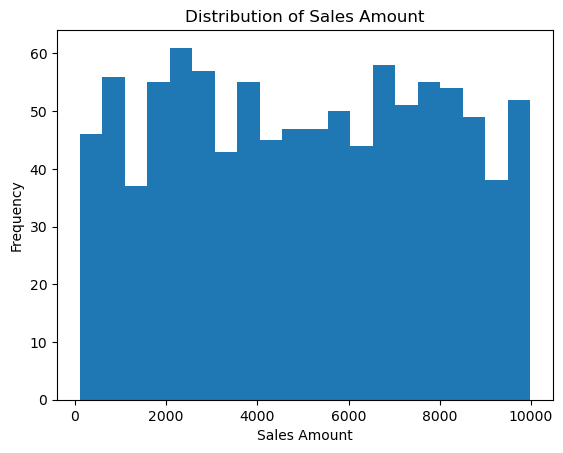

In [64]:
#SECTION 11: Simple Visual Exploration

import matplotlib.pyplot as plt

plt.hist(df['Sales_Amount'], bins=20)
plt.title("Distribution of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()